# Cav1.2 Timothy mutants: DI-S6 sliding and packing-register analysis

The question here is simple: do G402S and G406R make DI-S6 slide along DIV-S6, or do they loosen the interface in a less orderly way? WT, G402S, and G406R are compared under vanilla and masked protocols, with one final retained structure from each model–seed trajectory.

The primary metric is a **whole-interface nearest-partner register**, not a single mutation-site distance. For every structure, residues 400–408 in DI-S6 are matched to their nearest residue among DIV-S6 residues 1519–1535. The WT-vanilla modal map defines the reference packing register. The mutation site is excluded from the aggregate score so that the larger Arg side chain cannot by itself create an apparent helix slide.

The corrected July G406R tables are used because they contain complete shortest-heavy-atom and Cα matrices. The cross-condition register analysis uses shortest heavy-atom distances while excluding the mutation site from aggregate sliding scores; severe R406 overlap is tracked separately. Cα completeness is audited independently as a backbone-level safeguard.

In [1]:
from pathlib import Path
import csv, re, math, os
from collections import Counter, defaultdict
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

ROOT = Path.cwd().resolve()
if ROOT.name == 'cav12': ROOT = ROOT.parent
DATA = ROOT / 'cav12' / 'dataDistances'
OUT = DATA / 'analysis' / 's6_register'
OUT.mkdir(parents=True, exist_ok=True)

COLORS = {
 ('WT','vanilla'):'#DCEBF8', ('WT','masked'):'#3978B5',
 ('G402S','vanilla'):'#C8DAF6', ('G402S','masked'):'#315FAF',
 ('G406R','vanilla'):'#B8E2F0', ('G406R','masked'):'#217D9A',
}
CONDITIONS = [
 ('WT','vanilla','26-02-10_Cav12_wt_vanillaAF2_distances_all_ok_rmsd_3A.csv'),
 ('WT','masked','26-02-10_Cav12_wt_maskedAF2_distances_all_ok_rmsd_3A.csv'),
 ('G402S','vanilla','26-02-10_Cav12_g402s_vanillaAF2_distances_all_ok_rmsd_3A.csv'),
 ('G402S','masked','26-02-10_Cav12_g402s_maskedAF2_distances_all_ok_rmsd_3A.csv'),
 ('G406R','vanilla','26-07-25_Cav1.2_g406r_vanillaAF2_distances_all_ok_rmsd_3A.csv'),
 ('G406R','masked','26-07-25_Cav1.2_g406r_maskedAF2_distances_all_ok_rmsd_3A.csv'),
]
DI = list(range(400,409)); DIV = list(range(1519,1536))

def trajectory_key(path):
    m=re.search(r'model_(\d+)_seed_(\d+)\.r(\d+)\.pdb$', path)
    return ((int(m.group(1)),int(m.group(2))),int(m.group(3))) if m else (None,None)

def final_rows(path):
    with open(path,newline='') as h:
        rows=list(csv.DictReader(h))
    chosen={}
    for row in rows:
        key,r=trajectory_key(row['pdb_file'])
        if key is not None and (key not in chosen or r>chosen[key][0]): chosen[key]=(r,row)
    return [v[1] for v in chosen.values()]

def matrix_columns(fieldnames, prefix):
    out=defaultdict(list)
    pat=re.compile(rf'{prefix}_[A-Z]{{3}}(40[0-8])(?:_CA)?-[A-Z]{{3}}(15(?:19|2[0-9]|3[0-5]))(?:_CA)?$')
    for c in fieldnames:
        m=pat.match(c)
        if m: out[int(m.group(1))].append((c,int(m.group(2))))
    return out

def extract(rows, prefix='shortest'):
    cols=matrix_columns(rows[0].keys(),prefix)
    records=[]
    for row in rows:
        partners={}; minima={}
        for i in DI:
            vals=[]
            for c,j in cols.get(i,[]):
                try:
                    v=float(row[c])
                    if np.isfinite(v): vals.append((v,j))
                except (TypeError,ValueError): pass
            if vals:
                d,j=min(vals); partners[i]=j; minima[i]=d
        records.append({'pdb_file':row['pdb_file'],'partners':partners,'minima':minima})
    return records

datasets={}
for mutant,protocol,name in CONDITIONS:
    rows=final_rows(DATA/name)
    datasets[(mutant,protocol)]={'rows':rows,'heavy':extract(rows,'shortest'),'ca':extract(rows,'CA')}
    print(f'{mutant:5s} {protocol:7s}: {len(rows):3d} final trajectories; '
          f'heavy-atom complete={sum(len(x["partners"])==9 for x in datasets[(mutant,protocol)]["heavy"]):3d}; '
          f'Cα complete={sum(len(x["partners"])==9 for x in datasets[(mutant,protocol)]["ca"]):3d}')

WT    vanilla: 500 final trajectories; heavy-atom complete=500; Cα complete=500
WT    masked : 500 final trajectories; heavy-atom complete=500; Cα complete=500
G402S vanilla: 500 final trajectories; heavy-atom complete=500; Cα complete=500
G402S masked : 500 final trajectories; heavy-atom complete=500; Cα complete=500
G406R vanilla: 500 final trajectories; heavy-atom complete=500; Cα complete=500
G406R masked : 500 final trajectories; heavy-atom complete=500; Cα complete=500


## Register definition and quality control

Each DI-S6 residue has one nearest DIV-S6 partner. If the helix truly slides, several neighboring DI-S6 residues should change partners in the same direction—not just one residue at the mutation site. Two scores separate those possibilities:

- **Register displacement:** median change in nearest-partner residue number relative to the WT-vanilla modal partner map. Positive values indicate movement toward larger DIV-S6 residue numbers.
- **Register disruption:** fraction of evaluable DI-S6 residues whose nearest partner differs from the WT-vanilla modal map.

Positions 402 and 406 are excluded from their respective mutant scores. An R406-centered distance below 2 Å is treated as a severe overlap and reported separately. The remaining eight DI-S6 positions still provide a backbone-oriented readout even when the Arg side chain clashes; clash-free sensitivity summaries are shown whenever enough trajectories remain.

In [2]:
wt=datasets[('WT','vanilla')]['heavy']
WT_MAP={i:Counter(r['partners'][i] for r in wt if i in r['partners']).most_common(1)[0][0] for i in DI}
print('WT-vanilla modal DI-S6 → DIV-S6 nearest-partner map:')
print('  ' + ', '.join(f'{i}→{WT_MAP[i]}' for i in DI))

def severe_g406_overlap(rec):
    return any(d < 2.0 for i,d in rec['minima'].items() if i==406)

def score_records(mutant, records):
    exclude={402} if mutant=='G402S' else ({406} if mutant=='G406R' else set())
    ans=[]
    for rec in records:
        use=[i for i in DI if i not in exclude and i in rec['partners']]
        if len(use)<6: continue
        delta=np.array([rec['partners'][i]-WT_MAP[i] for i in use],float)
        ans.append({**rec,'severe_overlap': bool(mutant=='G406R' and severe_g406_overlap(rec)),
                    'register_shift':float(np.median(delta)),
                    'register_disruption':float(np.mean(delta!=0)),
                    'packing_gap':float(np.median([rec['minima'][i] for i in use]))})
    return ans

scores={}
for mutant,protocol,_ in CONDITIONS:
    raw=datasets[(mutant,protocol)]['heavy']
    scores[(mutant,protocol)]=score_records(mutant,raw)
    clash=sum(r.get('severe_overlap',False) for r in scores[(mutant,protocol)])
    print(f'{mutant:5s} {protocol:7s}: retained {len(scores[(mutant,protocol)])}/{len(raw)} after metric coverage; severe-overlap={clash}')

WT-vanilla modal DI-S6 → DIV-S6 nearest-partner map:
  400→1527, 401→1520, 402→1524, 403→1527, 404→1524, 405→1524, 406→1528, 407→1531, 408→1524
WT    vanilla: retained 500/500 after metric coverage; severe-overlap=0
WT    masked : retained 500/500 after metric coverage; severe-overlap=0
G402S vanilla: retained 500/500 after metric coverage; severe-overlap=0
G402S masked : retained 500/500 after metric coverage; severe-overlap=0
G406R vanilla: retained 500/500 after metric coverage; severe-overlap=149
G406R masked : retained 500/500 after metric coverage; severe-overlap=408


## Main comparison: sliding direction versus packing disruption

Read the three panels from left to right. The first asks whether the helix moves in one consistent direction. The second asks how often DI-S6 abandons its usual WT partner, even when those changes cancel out directionally. The third shows whether that repacking also pulls the helices farther apart. Violin width reflects how often a geometry appears in the predicted ensemble; it is not a thermodynamic population.

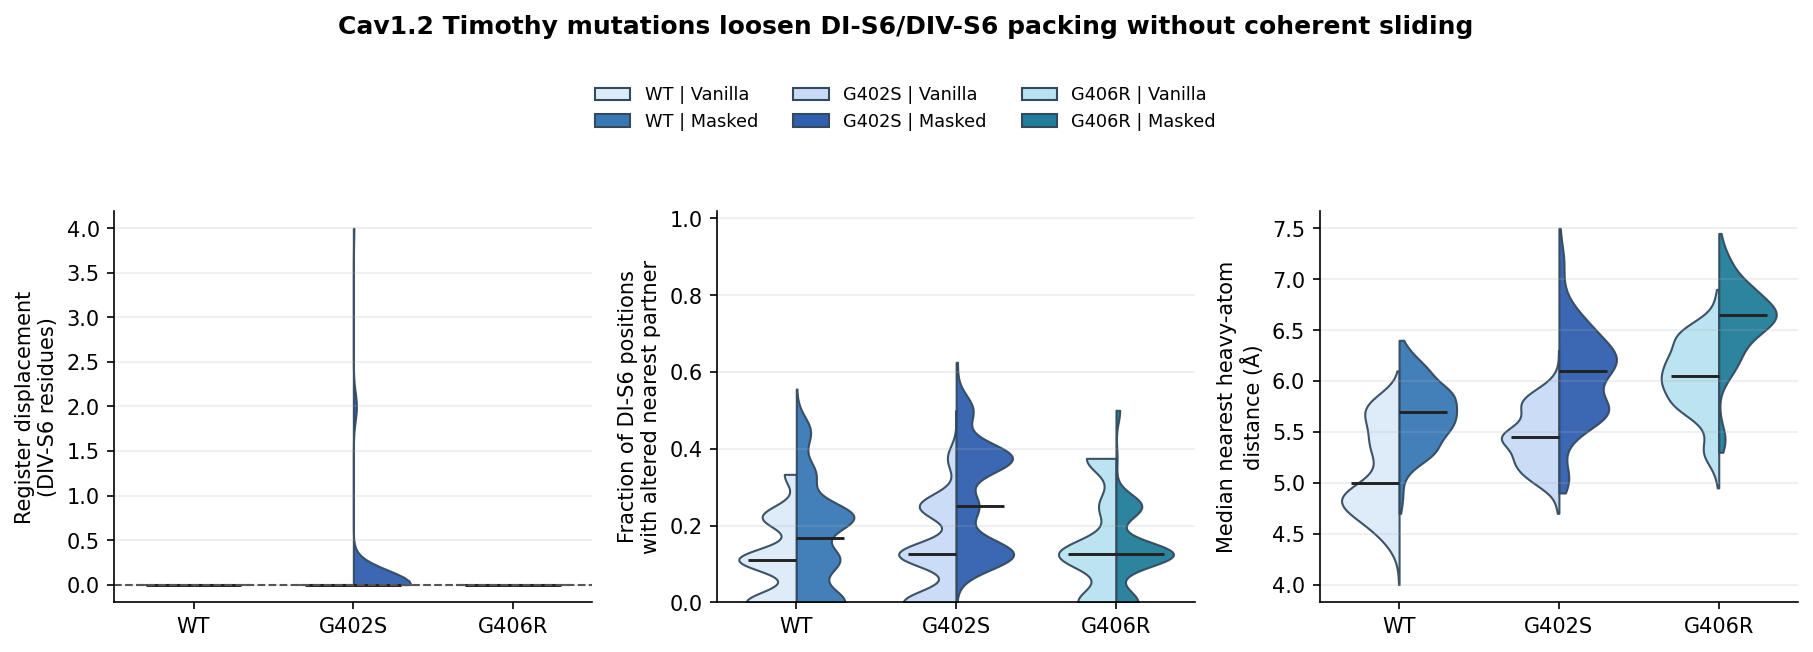

In [3]:
def violin_panel(ax, metric, ylabel, ylim=None):
    xs=[]; vals=[]; cols=[]; labels=[]
    x=0
    for mutant in ['WT','G402S','G406R']:
        for protocol in ['vanilla','masked']:
            v=np.array([r[metric] for r in scores[(mutant,protocol)]])
            pos=x
            p=ax.violinplot(v,[pos],widths=.72,showmedians=True,showextrema=False)
            for b in p['bodies']:
                b.set_facecolor(COLORS[(mutant,protocol)]);b.set_edgecolor('#334A5E');b.set_alpha(.95)
                for path in b.get_paths():
                    if protocol=='vanilla': path.vertices[:,0]=np.minimum(path.vertices[:,0],pos)
                    else: path.vertices[:,0]=np.maximum(path.vertices[:,0],pos)
            p['cmedians'].set_color('#222');p['cmedians'].set_linewidth(1.4)
            segments=p['cmedians'].get_segments()
            if segments:
                y=segments[0][0,1]
                segments[0]=np.array([[pos-.30 if protocol=='vanilla' else pos,y],
                                      [pos if protocol=='vanilla' else pos+.30,y]])
                p['cmedians'].set_segments(segments)
        labels.append(mutant);xs.append(x);x+=1
    ax.set_xticks(xs,labels);ax.set_ylabel(ylabel)
    ax.grid(axis='y',alpha=.22);ax.spines[['top','right']].set_visible(False)
    if ylim: ax.set_ylim(*ylim)

fig,axs=plt.subplots(1,3,figsize=(12.2,4.35))
violin_panel(axs[0],'register_shift','Register displacement\n(DIV-S6 residues)')
axs[0].axhline(0,color='#555',lw=1,ls='--')
violin_panel(axs[1],'register_disruption','Fraction of DI-S6 positions\nwith altered nearest partner',(0,1.02))
violin_panel(axs[2],'packing_gap','Median nearest heavy-atom\ndistance (Å)')
legend_handles=[Patch(facecolor=COLORS[(m,p)],edgecolor='#334A5E',label=f'{m} | {p.capitalize()}')
                for m in ['WT','G402S','G406R'] for p in ['vanilla','masked']]
fig.legend(handles=legend_handles,frameon=False,ncol=3,loc='upper center',bbox_to_anchor=(.5,.905),fontsize=8.5)
fig.suptitle('Cav1.2 Timothy mutations loosen DI-S6/DIV-S6 packing without coherent sliding',fontweight='bold',y=.99)
fig.tight_layout(rect=[0,0,1,.80]); fig.savefig(OUT/'cav12_s6_register_main.png',dpi=400,bbox_inches='tight'); plt.show()

## Where along DI-S6 does partner selection change?

The supplemental heatmaps show exactly where the partner changes occur. The absolute map gives the fraction of trajectories in which each DI-S6 residue chooses a particular DIV-S6 partner; white circles mark the usual WT-vanilla pairing. The offset map shows the same information relative to WT. A genuine slide should appear as a run of neighboring rows displaced to the same side of zero. Scattered changes instead point to local repacking.

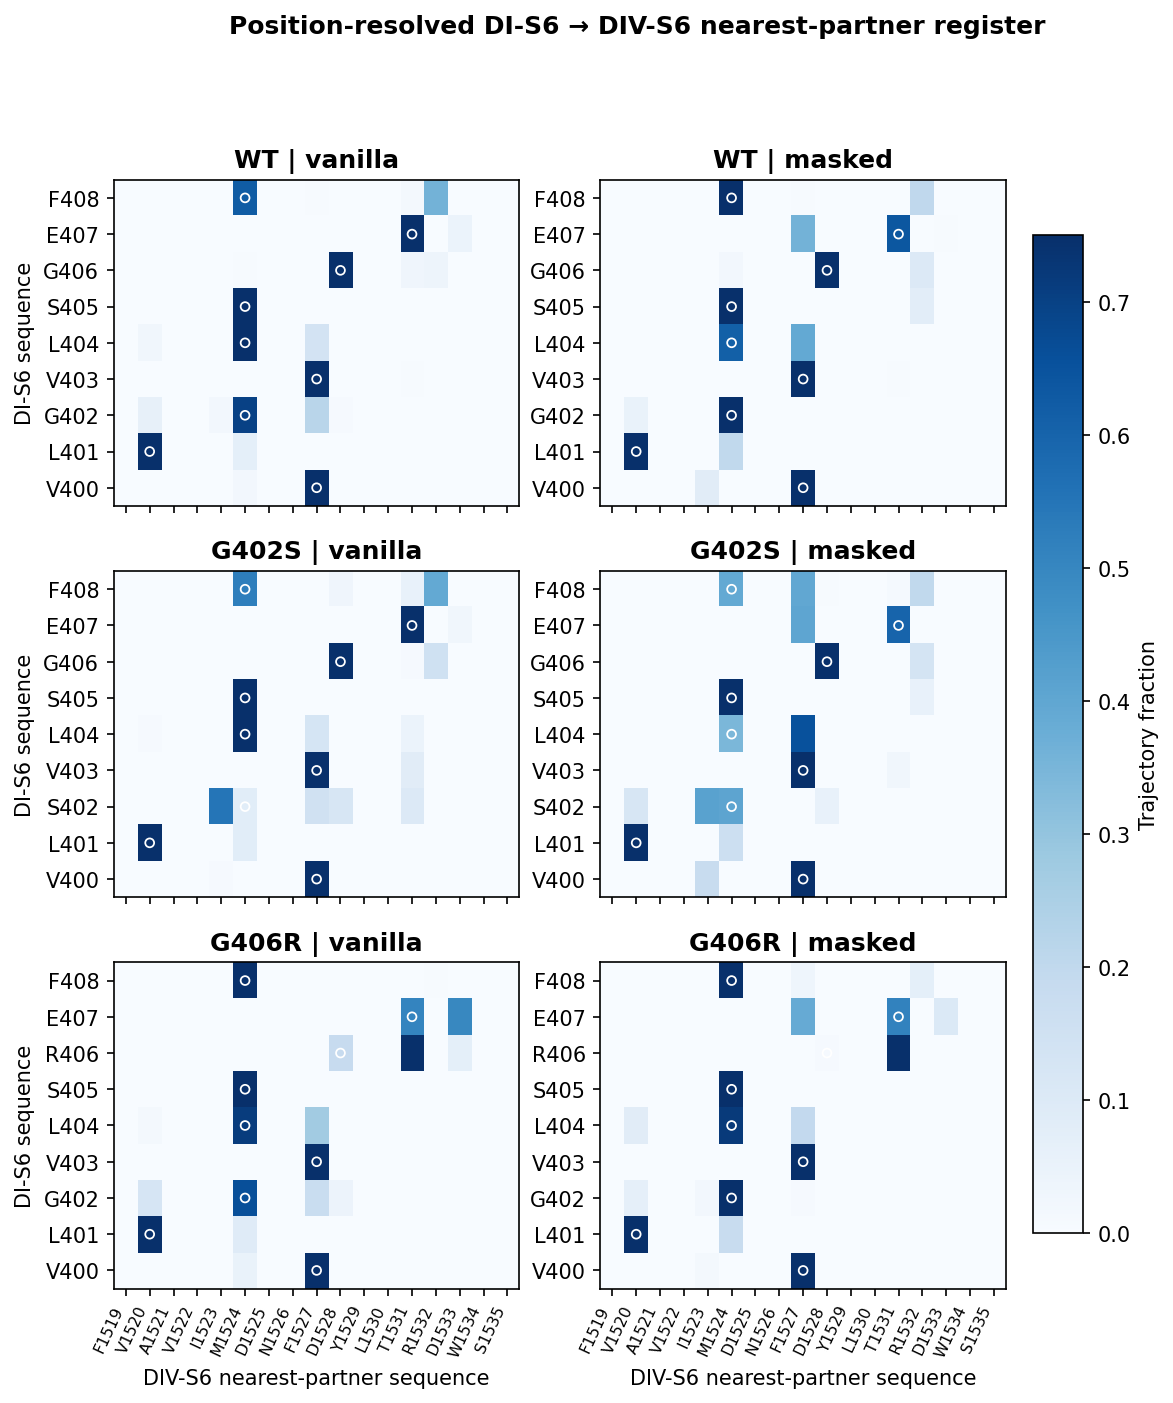

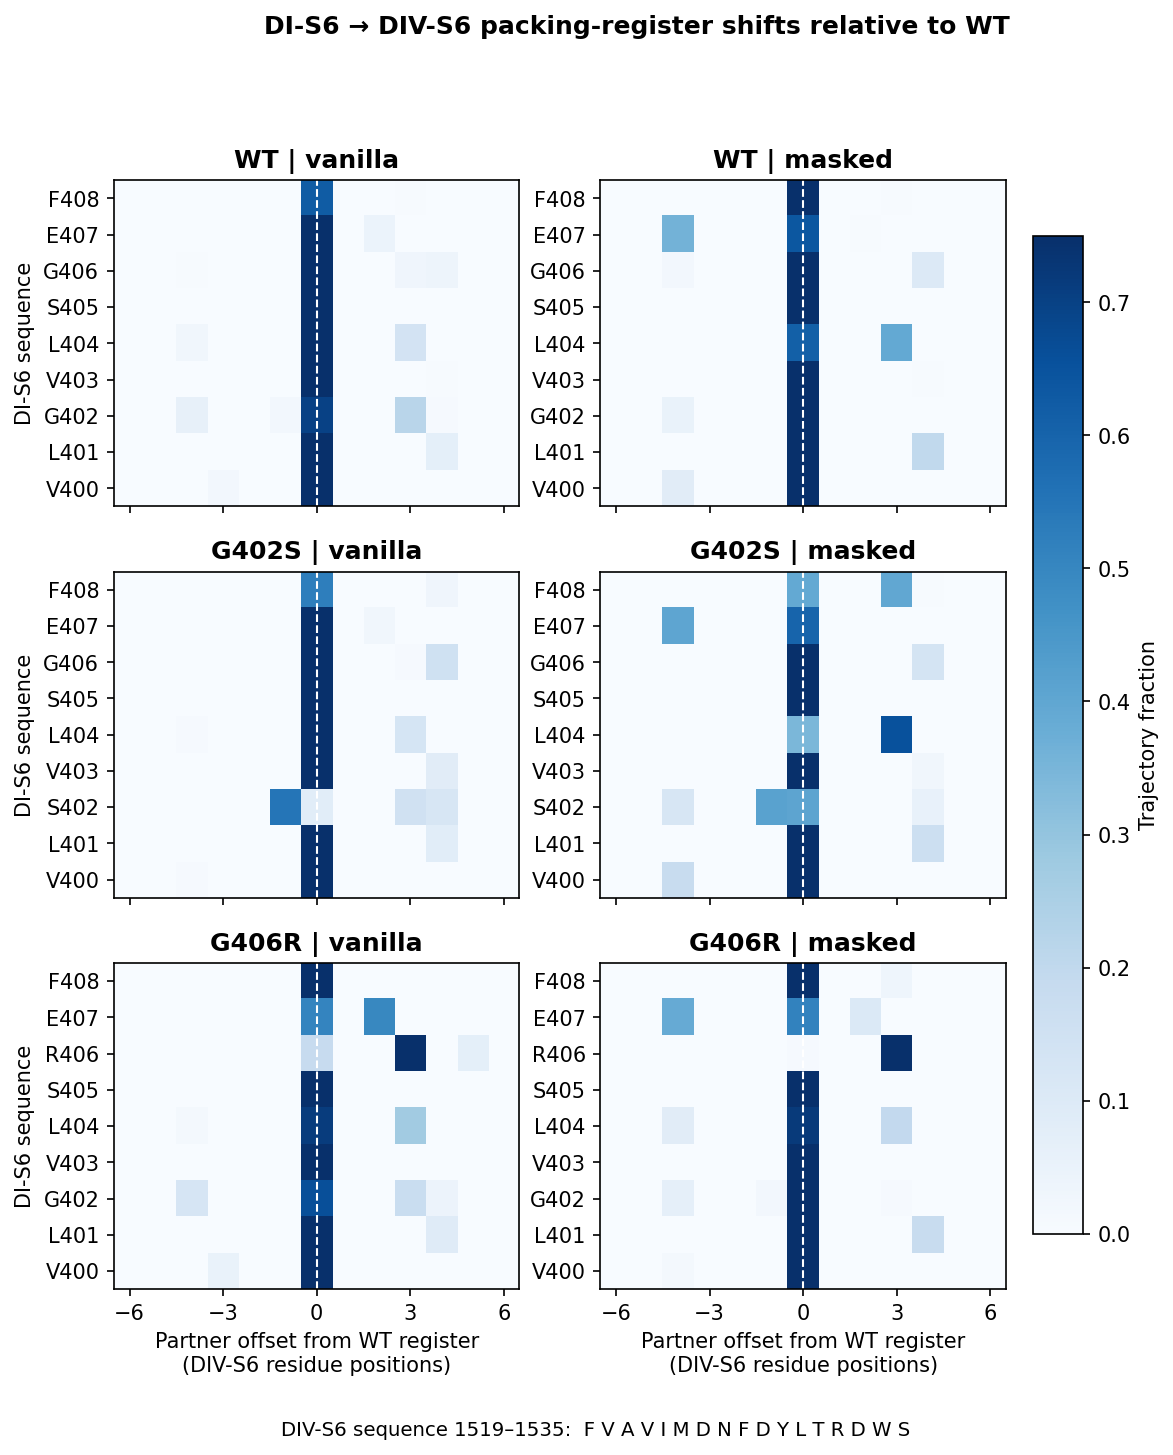

In [4]:
div_sequence={1519:'F',1520:'V',1521:'A',1522:'V',1523:'I',1524:'M',1525:'D',1526:'N',
              1527:'F',1528:'D',1529:'Y',1530:'L',1531:'T',1532:'R',1533:'D',1534:'W',1535:'S'}
fig,axs=plt.subplots(3,2,figsize=(9.3,9.6),sharex=True,sharey=False)
for ax,(mutant,protocol,_) in zip(axs.flat,CONDITIONS):
    recs=scores[(mutant,protocol)]
    M=np.zeros((len(DI),len(DIV)))
    for a,i in enumerate(DI):
        partners=[r['partners'][i] for r in recs if i in r['partners']]
        for b,j in enumerate(DIV): M[a,b]=np.mean(np.array(partners)==j) if partners else np.nan
    im=ax.imshow(M,origin='lower',aspect='auto',vmin=0,vmax=.75,cmap='Blues',extent=[1518.5,1535.5,399.5,408.5])
    ax.scatter([WT_MAP[i] for i in DI],DI,s=18,facecolors='none',edgecolors='white',linewidths=.85)
    ax.set_title(f'{mutant} | {protocol}',fontweight='bold')
    sequence={400:'V',401:'L',402:'S' if mutant=='G402S' else 'G',403:'V',404:'L',
              405:'S',406:'R' if mutant=='G406R' else 'G',407:'E',408:'F'}
    ax.set_xticks(DIV,[f'{div_sequence[j]}{j}' for j in DIV],rotation=65,ha='right',fontsize=7.5)
    ax.set_yticks(DI,[f'{sequence[i]}{i}' for i in DI])
for ax in axs[-1]: ax.set_xlabel('DIV-S6 nearest-partner sequence')
for ax in axs[:,0]: ax.set_ylabel('DI-S6 sequence')
cbar=fig.colorbar(im,ax=axs.ravel().tolist(),shrink=.90,pad=.025);cbar.set_label('Trajectory fraction')
fig.suptitle('Position-resolved DI-S6 → DIV-S6 nearest-partner register',fontweight='bold',y=.995)
fig.savefig(OUT/'cav12_s6_absolute_partner_heatmaps.png',dpi=400,bbox_inches='tight');plt.show()

# Supplemental register view: retain the WT-relative offset representation,
# but label DI-S6 with the actual sequence and provide the DIV-S6 sequence key.
offsets=np.arange(-6,7)
fig,axs=plt.subplots(3,2,figsize=(9.3,9.6),sharex=True,sharey=False)
for ax,(mutant,protocol,_) in zip(axs.flat,CONDITIONS):
    recs=scores[(mutant,protocol)]
    M=np.zeros((len(DI),len(offsets)))
    for a,i in enumerate(DI):
        ds=[r['partners'][i]-WT_MAP[i] for r in recs if i in r['partners']]
        for b,o in enumerate(offsets): M[a,b]=np.mean(np.array(ds)==o) if ds else np.nan
    im=ax.imshow(M,origin='lower',aspect='auto',vmin=0,vmax=.75,cmap='Blues',extent=[-6.5,6.5,399.5,408.5])
    ax.axvline(0,color='white',lw=1,ls='--')
    ax.set_title(f'{mutant} | {protocol}',fontweight='bold')
    sequence={400:'V',401:'L',402:'S' if mutant=='G402S' else 'G',403:'V',404:'L',
              405:'S',406:'R' if mutant=='G406R' else 'G',407:'E',408:'F'}
    ax.set_xticks([-6,-3,0,3,6]);ax.set_yticks(DI,[f'{sequence[i]}{i}' for i in DI])
for ax in axs[-1]: ax.set_xlabel('Partner offset from WT register\n(DIV-S6 residue positions)')
for ax in axs[:,0]: ax.set_ylabel('DI-S6 sequence')
cbar=fig.colorbar(im,ax=axs.ravel().tolist(),shrink=.90,pad=.025);cbar.set_label('Trajectory fraction')
fig.suptitle('DI-S6 → DIV-S6 packing-register shifts relative to WT',fontweight='bold',y=.995)
fig.text(.47,.008,'DIV-S6 sequence 1519–1535:  F V A V I M D N F D Y L T R D W S',ha='center',fontsize=9.5)
fig.savefig(OUT/'cav12_s6_partner_offset_heatmaps.png',dpi=400,bbox_inches='tight');plt.show()

## Trajectory-aware summaries and representative structures

Each model–seed trajectory contributes once, through its final retained structure. The confidence intervals therefore resample trajectories rather than correlated recycle snapshots. Representative G406R models are chosen for strong local repacking but little net sliding, with clash-free structures preferred. They are useful examples of the sampled mechanism, not validated endpoints for the mutant.

In [5]:
rng=np.random.default_rng(20260803)
def ci(v,fn=np.median,B=1000):
    v=np.asarray(v,float); bs=[fn(rng.choice(v,len(v),replace=True)) for _ in range(B)]
    return np.quantile(bs,[.025,.975])
summary=[]
for mutant,protocol,_ in CONDITIONS:
    recs=scores[(mutant,protocol)]
    for metric in ['register_shift','register_disruption','packing_gap']:
        v=np.array([r[metric] for r in recs]); lo,hi=ci(v)
        summary.append((mutant,protocol,metric,len(v),np.median(v),lo,hi))
print(f'{"Condition":18s} {"Metric":21s} {"N":>4s} {"Median [95% bootstrap CI]":>29s}')
for m,p,k,n,est,lo,hi in summary:
    print(f'{m+" | "+p:18s} {k:21s} {n:4d} {est:7.3f} [{lo:7.3f}, {hi:7.3f}]')

for protocol in ['vanilla','masked']:
    pool=[r for r in scores[('G406R',protocol)] if not r['severe_overlap']]
    if not pool: pool=scores[('G406R',protocol)]
    ranked=sorted(pool,key=lambda r:(-r['register_disruption'],abs(r['register_shift']),r['packing_gap']))[:10]
    out=OUT/f'g406r_{protocol}_register_candidates.csv'
    with open(out,'w',newline='') as h:
        w=csv.writer(h);w.writerow(['pdb_file','severe_overlap','register_shift_DIV_residues','register_disruption_fraction','median_nearest_heavy_A'])
        for r in ranked:w.writerow([r['pdb_file'],r['severe_overlap'],r['register_shift'],r['register_disruption'],r['packing_gap']])
    print(f'\nTop {protocol} G406R candidate: {ranked[0]["pdb_file"]}')
    print(f'  shift={ranked[0]["register_shift"]:.2f}; disruption={ranked[0]["register_disruption"]:.3f}; gap={ranked[0]["packing_gap"]:.2f} Å')

Condition          Metric                   N     Median [95% bootstrap CI]
WT | vanilla       register_shift         500   0.000 [  0.000,   0.000]
WT | vanilla       register_disruption    500   0.111 [  0.111,   0.111]
WT | vanilla       packing_gap            500   5.000 [  4.900,   5.100]
WT | masked        register_shift         500   0.000 [  0.000,   0.000]
WT | masked        register_disruption    500   0.167 [  0.111,   0.222]
WT | masked        packing_gap            500   5.700 [  5.600,   5.700]
G402S | vanilla    register_shift         500   0.000 [  0.000,   0.000]
G402S | vanilla    register_disruption    500   0.125 [  0.125,   0.125]
G402S | vanilla    packing_gap            500   5.450 [  5.400,   5.450]
G402S | masked     register_shift         500   0.000 [  0.000,   0.000]
G402S | masked     register_disruption    500   0.250 [  0.250,   0.375]
G402S | masked     packing_gap            500   6.100 [  6.050,   6.150]
G406R | vanilla    register_shift         500   

## Backbone Cα coverage audit

As a backbone check, every trajectory should contain the full 9 × 17 Cα distance matrix. The corrected July G406R tables pass this audit. The older February tables do not contain the complete mutation-interface matrix and should not be used for this analysis.

In [6]:
for mutant,protocol,_ in CONDITIONS:
    recs=datasets[(mutant,protocol)]['ca']
    complete=[r for r in recs if len(r['partners'])==9]
    status='OK' if len(complete)>=0.9*len(recs) else 'INCOMPLETE — regeneration required'
    print(f'{mutant:5s} {protocol:7s}: {len(complete):3d}/{len(recs):3d} complete Cα matrices | {status}')

ca_wt=datasets[('WT','vanilla')]['ca']
CA_WT_MAP={i:Counter(r['partners'][i] for r in ca_wt).most_common(1)[0][0] for i in DI}
print('\nCα sensitivity analysis (mutation site excluded):')
print(f'{"Condition":18s} {"register shift":>15s} {"disruption":>12s} {"Cα gap (Å)":>12s}')
for mutant,protocol,_ in CONDITIONS:
    exclude={402} if mutant=='G402S' else ({406} if mutant=='G406R' else set())
    vals=[]
    for r in datasets[(mutant,protocol)]['ca']:
        use=[i for i in DI if i not in exclude and i in r['partners']]
        d=np.array([r['partners'][i]-CA_WT_MAP[i] for i in use])
        vals.append((np.median(d),np.mean(d!=0),np.median([r['minima'][i] for i in use])))
    a=np.asarray(vals)
    print(f'{mutant+" | "+protocol:18s} {np.median(a[:,0]):15.3f} {np.median(a[:,1]):12.3f} {np.median(a[:,2]):12.3f}')

WT    vanilla: 500/500 complete Cα matrices | OK
WT    masked : 500/500 complete Cα matrices | OK
G402S vanilla: 500/500 complete Cα matrices | OK
G402S masked : 500/500 complete Cα matrices | OK
G406R vanilla: 500/500 complete Cα matrices | OK
G406R masked : 500/500 complete Cα matrices | OK

Cα sensitivity analysis (mutation site excluded):
Condition           register shift   disruption   Cα gap (Å)
WT | vanilla                 0.000        0.333        8.370
WT | masked                  0.000        0.333        8.890
G402S | vanilla              0.000        0.250        8.845
G402S | masked              -0.500        0.500        9.210
G406R | vanilla              0.000        0.250        9.205
G406R | masked               0.000        0.375        9.750


## How to read the result

- A shifted **register-displacement** distribution, together with several consecutive heatmap rows moving in the same direction, would support axial sliding.
- More **register disruption** without a consistent direction means that the interface is repacking rather than translating as one helix.
- A larger **packing gap** means that DI-S6 and DIV-S6 are separating. If the gap stays similar while partners change, the interface is rearranging without opening appreciably.
- G406R should always be checked with the clash flag and the Cα result, because its Arg side chain can dominate a shortest-distance measurement.

Taken together, the heavy-atom and Cα measurements support a restrained conclusion: the Timothy mutations alter DI-S6/DIV-S6 packing, but the present ensembles do not show a single, coherent sliding register. G402S samples heterogeneous partner changes, while G406R more clearly increases interhelical separation.